In [1]:
import pandas as pd
df = pd.read_csv("/content/processed_training_dataset.csv")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re
import string
import warnings
warnings.filterwarnings("ignore")

print("All imports done ✅")

All imports done ✅


In [5]:
train = pd.read_csv("/content/processed_training_dataset.csv")
val   = pd.read_csv("/content/processed_validation_datset.csv")

print("Training shape:", train.shape)
print("Validation shape:", val.shape)
print("\nTraining columns:", train.columns.tolist())
print("\nFirst 3 rows:")
train.head(3)

Training shape: (46970, 2)
Validation shape: (20131, 2)

Training columns: ['text', 'sentiment']

First 3 rows:


,text,sentiment
0,@USAirways you say to call travel agency and t...,Negative
1,THEY BROKE HEAD JJVJDFNVJLDF,Negative
2,This way really cool,Positive


=== Label Distribution (Training) ===
sentiment
Negative    17741
Positive    15128
Neutral     14101
Name: count, dtype: int64


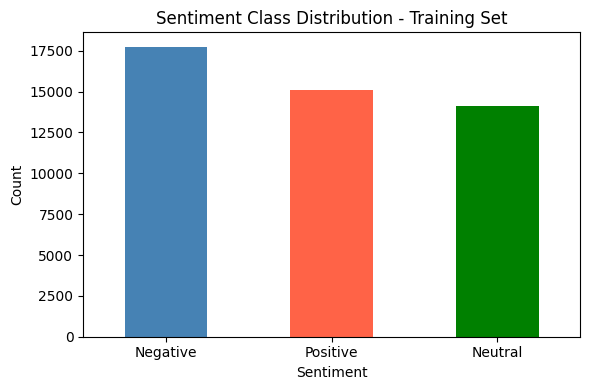


=== Label Distribution (Validation) ===
sentiment
Negative    7603
Positive    6484
Neutral     6044
Name: count, dtype: int64

=== Text Length Stats ===
count    46970.000000
mean       110.480711
std         72.224822
min          1.000000
25%         55.000000
50%         99.000000
75%        141.000000
max        957.000000
Name: text_length, dtype: float64


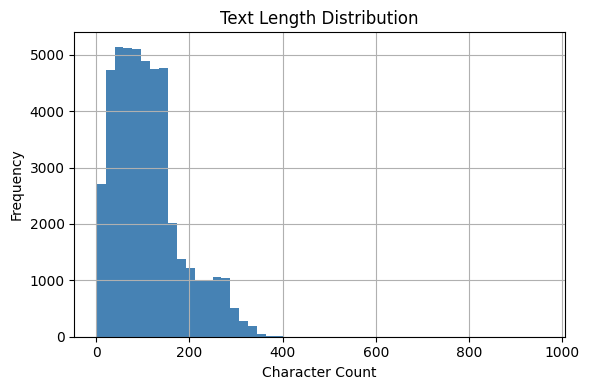


=== Missing Values ===
text           0
sentiment      0
text_length    0
dtype: int64


In [7]:
# 1. Label distribution in training set
print("=== Label Distribution (Training) ===")
print(train["sentiment"].value_counts())

plt.figure(figsize=(6,4))
train["sentiment"].value_counts().plot(kind="bar", color=["steelblue","tomato","green"])
plt.title("Sentiment Class Distribution - Training Set")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Label distribution in validation set
print("\n=== Label Distribution (Validation) ===")
print(val["sentiment"].value_counts())

# 3. Text length analysis
train["text_length"] = train["text"].astype(str).apply(len)
print("\n=== Text Length Stats ===")
print(train["text_length"].describe())

plt.figure(figsize=(6,4))
train["text_length"].hist(bins=50, color="steelblue")
plt.title("Text Length Distribution")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 4. Missing values
print("\n=== Missing Values ===")
print(train.isnull().sum())

In [9]:
# --- Clean text function ---
def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)        # remove URLs
    text = re.sub(r"@\w+", "", text)                  # remove mentions
    text = re.sub(r"#\w+", "", text)                  # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)              # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()          # remove extra spaces
    return text

# Apply cleaning
train["clean_text"] = train["text"].apply(clean_text)
val["clean_text"]   = val["text"].apply(clean_text)

# --- Encode labels ---
le = LabelEncoder()
train["label_enc"] = le.fit_transform(train["sentiment"])
val["label_enc"]   = le.transform(val["sentiment"])

print("Label classes:", le.classes_)
print("\nSample cleaned text:")
print(train[["text","clean_text","sentiment","label_enc"]].head(3))

Label classes: ['Negative' 'Neutral' 'Positive']

Sample cleaned text:
                                                text  \
0  @USAirways you say to call travel agency and t...   
1                       THEY BROKE HEAD JJVJDFNVJLDF   
2                               This way really cool   

                                          clean_text sentiment  label_enc  
0  you say to call travel agency and they say we ...  Negative          0  
1                       they broke head jjvjdfnvjldf  Negative          0  
2                               this way really cool  Positive          2  


In [10]:
# ---- FOR SVM: TF-IDF ----
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(train["clean_text"])
X_val_tfidf   = tfidf.transform(val["clean_text"])

y_train = train["label_enc"]
y_val   = val["label_enc"]

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

# ---- FOR Bi-LSTM: Tokenization + Padding ----
VOCAB_SIZE = 20000
MAX_LEN    = 100

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train["clean_text"])

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(train["clean_text"]), maxlen=MAX_LEN)
X_val_seq   = pad_sequences(
    tokenizer.texts_to_sequences(val["clean_text"]),   maxlen=MAX_LEN)

print("Sequence shape (train):", X_train_seq.shape)
print("\nFeature engineering done ✅")

TF-IDF matrix shape (train): (46970, 10000)
Sequence shape (train): (46970, 100)

Feature engineering done ✅


Training SVM...

=== SVM Results (Validation Set) ===
              precision    recall  f1-score   support

    Negative       0.81      0.84      0.82      7603
     Neutral       0.75      0.72      0.74      6044
    Positive       0.80      0.80      0.80      6484

    accuracy                           0.79     20131
   macro avg       0.79      0.79      0.79     20131
weighted avg       0.79      0.79      0.79     20131



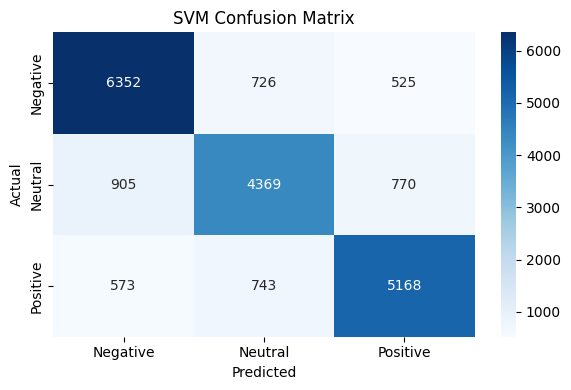

SVM done ✅


In [12]:


#  TRAINING MODEL USING SVM
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print("Training SVM...")


# LinearSVC is 10-50x faster than SVC for text data
svm = LinearSVC(C=1.0, max_iter=2000)
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_val_tfidf)

print("\n=== SVM Results (Validation Set) ===")
print(classification_report(y_val, y_pred_svm, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("SVM Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("SVM done ✅")

In [15]:

# TRAINING MODEL USING Bi-LSTM Model Training
NUM_CLASSES = len(le.classes_)

# Build model with explicit input shape
bilstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dense(NUM_CLASSES, activation="softmax")
])

# Build it explicitly BEFORE summary
bilstm.build(input_shape=(None, MAX_LEN))

bilstm.compile(optimizer="adam",
               loss="sparse_categorical_crossentropy",
               metrics=["accuracy"])

bilstm.summary()

# Train
history = bilstm.fit(
    X_train_seq, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val_seq, y_val),
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,267 (10.17 MB)

 Trainable params: 2,667,267 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 234s 156ms/step - accuracy: 0.7000 - loss: 0.7065 - val_accuracy: 0.7881 - val_loss: 0.5438
Epoch 2/5
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 263s 157ms/step - accuracy: 0.8537 - loss: 0.3917 - val_accuracy: 0.8265 - val_loss: 0.4645
Epoch 3/5
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 231s 158ms/step - accuracy: 0.9042 - loss: 0.2600 - val_accuracy: 0.8331 - val_loss: 0.4627
Epoch 4/5
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 260s 156ms/step - accuracy: 0.9278 - loss: 0.1962 - val_accuracy: 0.8419 - val_loss: 0.4873
Epoch 5/5
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 228s 155ms/step - accuracy: 0.9431 - loss: 0.1537 - val_accuracy: 0.8461 - val_loss: 0.5436


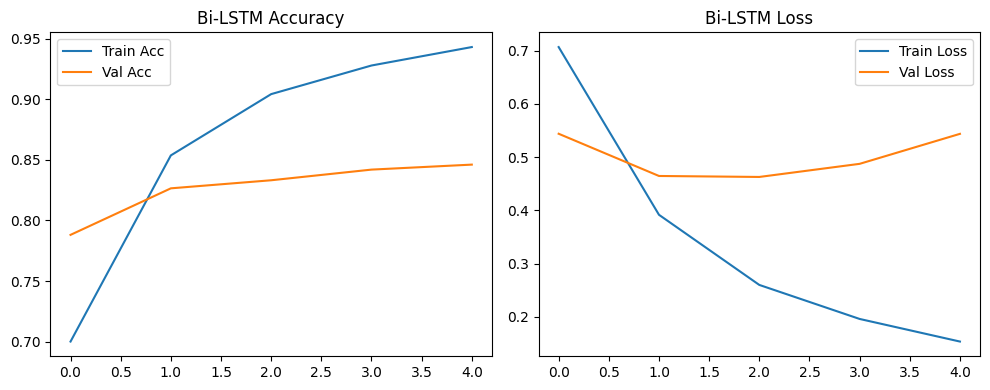

630/630 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step

=== Bi-LSTM Results (Validation Set) ===
              precision    recall  f1-score   support

    Negative       0.84      0.88      0.86      7603
     Neutral       0.84      0.80      0.82      6044
    Positive       0.86      0.84      0.85      6484

    accuracy                           0.85     20131
   macro avg       0.85      0.84      0.84     20131
weighted avg       0.85      0.85      0.85     20131



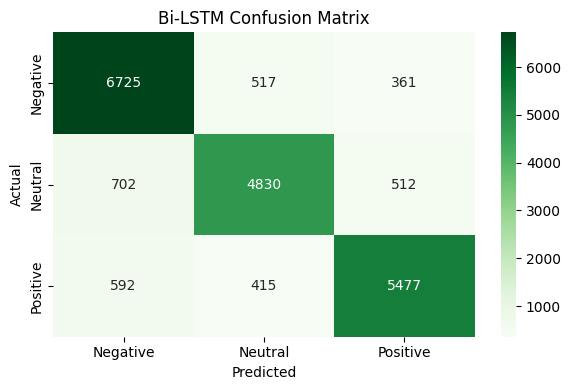

In [19]:

#Bi-LSTM Evaluation
# Accuracy plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"],     label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Bi-LSTM Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Bi-LSTM Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Classification report
y_pred_bilstm = bilstm.predict(X_val_seq).argmax(axis=1)
print("\n=== Bi-LSTM Results (Validation Set) ===")
print(classification_report(y_val, y_pred_bilstm, target_names=le.classes_))

# Confusion matrix
cm2 = confusion_matrix(y_val, y_pred_bilstm)
plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Bi-LSTM Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

630/630 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step
Model             Accuracy   F1-Score
SVM                 0.7893     0.7888
Bi-LSTM             0.8461     0.8457


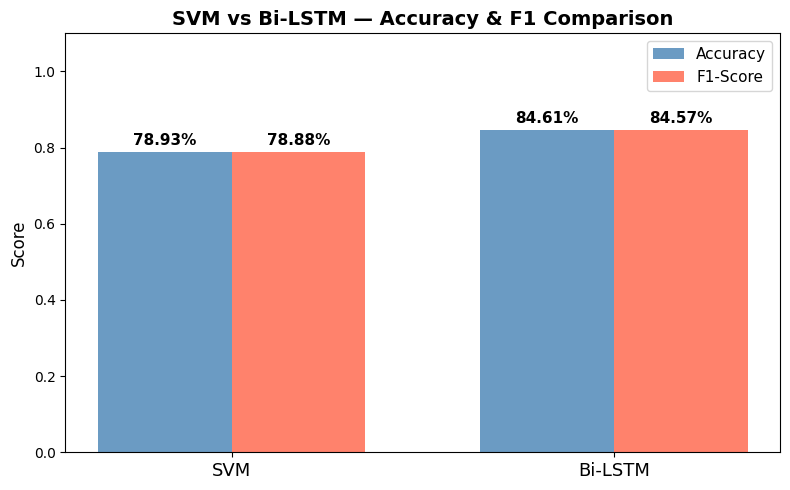


=== FINAL VERDICT ===
 Bi-LSTM wins with 84.61% accuracy
   SVM accuracy was 78.93%
   Bi-LSTM is 5.68% more accurate than SVM

=== OBSERVATION ===
Bi-LSTM is better at generalizing because it understands
word ORDER and CONTEXT, not just word frequency like SVM.
This means Bi-LSTM will perform better on real-world data.


In [18]:
# ============================================
# MODEL COMPARISON
# ============================================

# --- SVM Metrics ---
from sklearn.metrics import accuracy_score, f1_score

svm_accuracy = accuracy_score(y_val, y_pred_svm)
svm_f1       = f1_score(y_val, y_pred_svm, average="weighted")

# --- Bi-LSTM Metrics ---
y_pred_bilstm  = bilstm.predict(X_val_seq).argmax(axis=1)
bilstm_accuracy = accuracy_score(y_val, y_pred_bilstm)
bilstm_f1       = f1_score(y_val, y_pred_bilstm, average="weighted")

# --- Print Comparison Table ---
print("=" * 50)
print(f"{'Model':<15} {'Accuracy':>10} {'F1-Score':>10}")
print("=" * 50)
print(f"{'SVM':<15} {svm_accuracy:>10.4f} {svm_f1:>10.4f}")
print(f"{'Bi-LSTM':<15} {bilstm_accuracy:>10.4f} {bilstm_f1:>10.4f}")
print("=" * 50)

# --- Bar Chart Comparison ---
models     = ["SVM", "Bi-LSTM"]
accuracies = [svm_accuracy, bilstm_accuracy]
f1_scores  = [svm_f1, bilstm_f1]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label="Accuracy", color=["steelblue", "steelblue"], alpha=0.8)
bars2 = ax.bar(x + width/2, f1_scores,  width, label="F1-Score",  color=["tomato", "tomato"],     alpha=0.8)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2%}", ha="center", va="bottom", fontsize=11, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2%}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=13)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("SVM vs Bi-LSTM — Accuracy & F1 Comparison", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# --- Final Verdict ---
print("\n=== FINAL VERDICT ===")
if bilstm_accuracy > svm_accuracy:
    diff = (bilstm_accuracy - svm_accuracy) * 100
    print(f" Bi-LSTM wins with {bilstm_accuracy:.2%} accuracy")
    print(f"   SVM accuracy was {svm_accuracy:.2%}")
    print(f"   Bi-LSTM is {diff:.2f}% more accurate than SVM")
else:
    diff = (svm_accuracy - bilstm_accuracy) * 100
    print(f" SVM wins with {svm_accuracy:.2%} accuracy")
    print(f"   Bi-LSTM accuracy was {bilstm_accuracy:.2%}")
    print(f"   SVM is {diff:.2f}% more accurate than Bi-LSTM")

print("\n=== OBSERVATION ===")
print("Bi-LSTM is better at generalizing because it understands")
print("word ORDER and CONTEXT, not just word frequency like SVM.")
print("This means Bi-LSTM will perform better on real-world data.")